# Simulacion de eventos y envio a traves de Analog Discover

Aqui tienen un script para la simulacion de los eventos y las alturas dependiendo de una distribucion definida

### Importar Librerias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pydwf.utilities import openDwfDevice
from pydwf import DwfLibrary
from pydwf.core.api.analog_out import DwfAnalogOutNode, DwfAnalogOutFunction
import time

### Modelo de pulso

In [2]:
# Definición de la forma del pulso
def radiation_event(t, A, t_0, tau_D, tau_R):
    return (A * ((np.exp(-(t - t_0) / tau_D) - np.exp(-(t - t_0) / tau_R)))) * np.heaviside(t - t_0, 1)

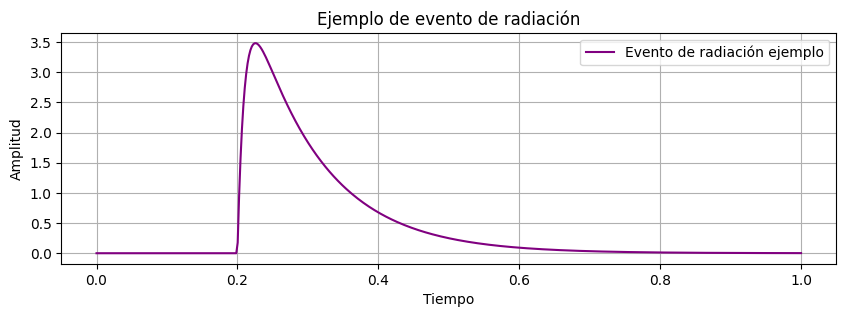

In [3]:
# Ejemplo de un evento de radiación
example_t = np.linspace(0, 1, 500)
example_A = 5  # Amplitud
example_t_0 = 0.2  # Tiempo inicial
example_tau_D = 0.1  # Decaimiento
example_tau_R = 0.01  # Subida
example_pulse = radiation_event(example_t, example_A, example_t_0, example_tau_D, example_tau_R)

plt.figure(figsize=(10, 3))
plt.plot(example_t, example_pulse, label='Evento de radiación ejemplo', color='purple')
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')
plt.title('Ejemplo de evento de radiación')
plt.legend()
plt.grid()
plt.show()

### Creacion de funcion de distribucion de alturas

In [33]:
def monte_carlo_pdf_optimized(num_samples, min_value=1.5, max_value=30, plot=False):
    """
    Genera muestras a partir de una función de probabilidad arbitraria utilizando muestreo eficiente.
    
    Utiliza el muestreo inverso basado en la función de distribución acumulada (CDF).
    
    Parameters:
    - num_samples: número de muestras a generar.
    - min_value: valor mínimo de energía.
    - max_value: valor máximo de energía.
    
    Returns:
    - distribucion: muestras generadas a partir de la función senoidal.
    """
    # Generar la función senoidal normalizada
    x = np.linspace(0, 2 * np.pi, num_samples)

    pdf_senoidal = np.abs(8*np.exp(-1 * ((x-1.7)/0.15)**2) + 10*np.exp(-1 * ((x-2)/0.07)**2) + 2*np.exp(-1 * (x-4)**2) + 3*np.exp(-1 * ((x-3.5)/0.1)**2) - 1.5*np.exp(-1 * ((x-4.5)/0.1)**2))  # Usar valor absoluto para que sea positiva
    
    # Normalizar la PDF para que su área sea 1 (función de densidad de probabilidad válida)
    pdf_senoidal /= np.sum(pdf_senoidal)
    
    # Calcular la CDF (integración acumulativa)
    cdf_senoidal = np.cumsum(pdf_senoidal)
    cdf_senoidal /= cdf_senoidal[-1]  # Normalizar la CDF para que termine en 1
    
    # Generar muestras aleatorias en el intervalo [0, 1] para la CDF
    uniform_samples = np.random.uniform(0, 1, num_samples)
    
    # Encontrar los índices en la CDF correspondientes a las muestras uniformemente distribuidas
    indices = np.searchsorted(cdf_senoidal, uniform_samples)
    
    # Mapear los índices a las energías
    energy_values = np.linspace(min_value, max_value, num_samples)
    samples = energy_values[indices]

    if plot:   
        # Graficar PDF y CDF
        plt.figure(figsize=(12, 4))

        # Gráfico de la PDF
        plt.subplot(1, 2, 1)
        plt.plot(x, pdf_senoidal, color='purple', label='PDF senoidal')
        plt.xlabel('Valor de Energía (eV)')
        plt.ylabel('Densidad de Probabilidad')
        plt.title('Función de Densidad de Probabilidad (PDF)')
        plt.grid()
        plt.legend()

        # Gráfico de la CDF
        plt.subplot(1, 2, 2)
        plt.plot(x, cdf_senoidal, color='blue', label='CDF senoidal')
        plt.xlabel('Valor de Energía (eV)')
        plt.ylabel('Probabilidad Acumulada')
        plt.title('Función de Distribución Acumulada (CDF)')
        plt.grid()
        plt.legend()

        plt.tight_layout()
        plt.show() 
        
    
    return samples

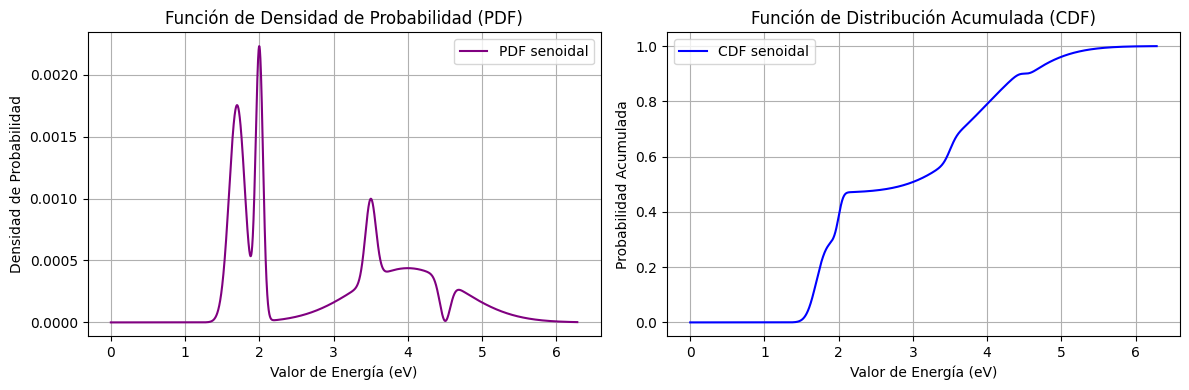

In [34]:
# Generar alturas usando Monte Carlo
num_pulsos = 4000
alturas = monte_carlo_pdf_optimized(num_pulsos, plot=True)


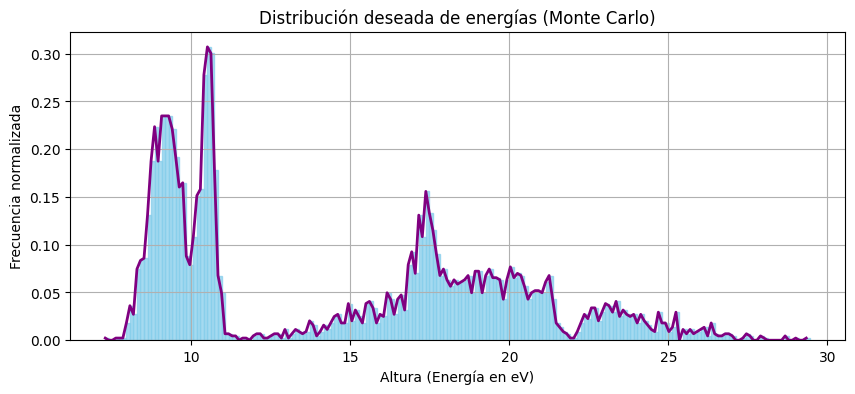

In [42]:
# Visualizar la distribución deseada (bimodal con Poisson y Gaussiana) en línea continua
plt.figure(figsize=(10, 4))
# Generar un histograma de la distribución sin bins y graficarlo como una línea continua
count, bins, ignored = plt.hist(alturas, bins=200, alpha=0.75, edgecolor='skyblue', color='skyblue', density=True)
# Graficar la distribución de la altura de los pulsos como una línea
plt.plot(bins[:-1], count, color='purple', lw=2)
plt.xlabel('Altura (Energía en eV)')
plt.ylabel('Frecuencia normalizada')
plt.title('Distribución deseada de energías (Monte Carlo)')
plt.grid()
plt.show()


In [36]:
# --- Exportar el vector a un archivo CSV ---
filename = "alturas.csv"
df = pd.DataFrame(alturas, columns=["Values"])  # Crear un DataFrame
df.to_csv(filename, index=False)  # Exportar a CSV sin el índice
print(f"Vector exportado a {filename}")

Vector exportado a alturas.csv


### Carga de datos de alturas y generacion de pulsos con Analog Discover


Vector cargado desde el CSV:


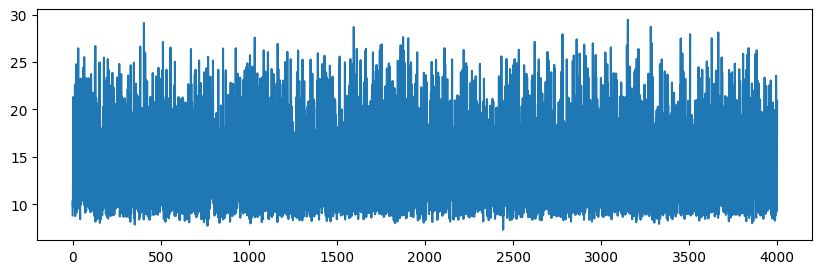

In [37]:
# --- Cargar el vector desde el archivo CSV ---
filename = "alturas.csv"
loaded_df = pd.read_csv(filename)  # Leer el archivo CSV
loaded_vector = loaded_df["Values"].values  # Convertir la columna de nuevo a un array
print("Vector cargado desde el CSV:")
plt.figure(figsize=(10,3))
plt.plot(loaded_vector)

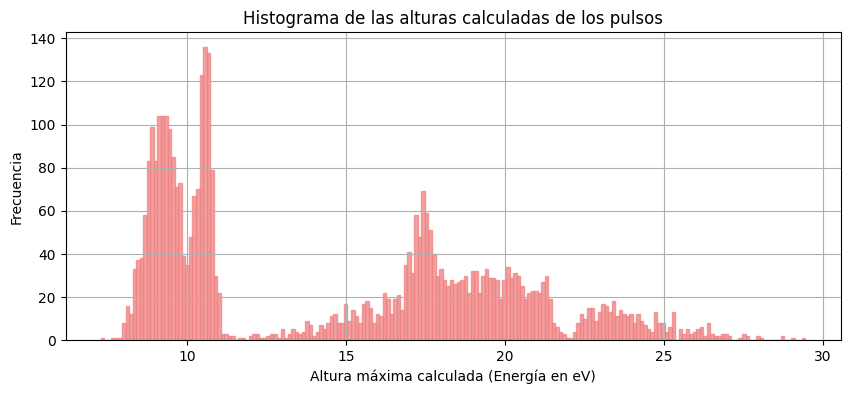

In [41]:
plt.figure(figsize=(10, 4))
plt.hist(loaded_vector, bins=200, alpha=0.75, edgecolor='lightcoral', color='lightcoral')
plt.xlabel('Altura máxima calculada (Energía en eV)')
plt.ylabel('Frecuencia')
plt.title('Histograma de las alturas calculadas de los pulsos')
plt.grid()
plt.show()

### Parametros de simulacion

In [43]:
# --- Configuración de parámetros ---
fs = 1e6  # Frecuencia de muestreo: 1 MHz
duration = 0.02  # Duración total de cada pulso (en segundos)
num_points = int(fs * duration)

# Modelo de la señal: pulso único
def radiation_event(t, t_0, A, tau_D, tau_R):
    return A * (np.exp(-(t - t_0) / tau_D) - np.exp(-(t - t_0) / tau_R))

# Especificar los parámetros de los pulsos
pulse_amplitudes = loaded_vector  # Alturas de los pulsos
pulse_positions = 0.0002 * np.ones(len(loaded_vector))  # Posiciones iniciales dentro del rango de tiempo
tau_D, tau_R = 0.000025, 0.000001  # Constantes de decaimiento

### Implementacion en Analog Discover

In [45]:
# Crear instancia de la biblioteca DWF
dwf = DwfLibrary()

# --- Conectar al dispositivo Analog Discovery ---
with openDwfDevice(dwf) as device:  # Abre el dispositivo conectado
    print("Analog Discovery conectado.")

    analog_out = device.analogOut

    # Configurar el Waveform Generator
    analog_out.nodeEnableSet(0, DwfAnalogOutNode.Carrier, True)  # Habilitar el nodo de salida
    analog_out.nodeFunctionSet(0, DwfAnalogOutNode.Carrier, DwfAnalogOutFunction.Custom)  # Señal personalizada

    # Iterar sobre los pulsos y enviarlos
    for i, (A, t_0) in enumerate(zip(pulse_amplitudes, pulse_positions)):
        print(f"Generando pulso {i+1} con amplitud {A} y tiempo inicial {t_0}s.")

        # Generar el pulso
        t = np.linspace(0, duration, num_points)
        pulse = radiation_event(t, t_0, A, tau_D, tau_R)
        pulse[t < t_0] = 0  # Limitar el pulso a valores después de t_0

        # Normalizar el pulso
        pulse = pulse / np.max(pulse_amplitudes)   # Escalar a rango -2V a +2V

        # Configurar y enviar el pulso al Wavegen
        analog_out.nodeDataSet(0, DwfAnalogOutNode.Carrier, pulse)
        analog_out.frequencySet(0, fs / num_points)  # Configurar frecuencia de muestreo
        analog_out.amplitudeSet(0, 1)
        analog_out.configure(0, True)  # Iniciar la salida
        print(f"Pulso {i+1} enviado.")

        # Esperar antes de enviar el siguiente pulso
        time.sleep(duration)  # Ajustar el tiempo de espera según sea necesario

    # Apagar el generador al finalizar
    analog_out.configure(0, False)
    print("Generación de pulsos finalizada.")

Analog Discovery conectado.
Generando pulso 1 con amplitud 8.8192048012003 y tiempo inicial 0.0002s.
Pulso 1 enviado.
Generando pulso 2 con amplitud 10.379969992498124 y tiempo inicial 0.0002s.
Pulso 2 enviado.
Generando pulso 3 con amplitud 9.710052513128282 y tiempo inicial 0.0002s.
Pulso 3 enviado.
Generando pulso 4 con amplitud 21.283945986496622 y tiempo inicial 0.0002s.
Pulso 4 enviado.
Generando pulso 5 con amplitud 19.86571642910728 y tiempo inicial 0.0002s.
Pulso 5 enviado.
Generando pulso 6 con amplitud 9.75993998499625 y tiempo inicial 0.0002s.
Pulso 6 enviado.
Generando pulso 7 con amplitud 20.051012753188296 y tiempo inicial 0.0002s.
Pulso 7 enviado.
Generando pulso 8 con amplitud 19.587771942985743 y tiempo inicial 0.0002s.
Pulso 8 enviado.
Generando pulso 9 con amplitud 18.19804951237809 y tiempo inicial 0.0002s.
Pulso 9 enviado.
Generando pulso 10 con amplitud 17.44973743435859 y tiempo inicial 0.0002s.
Pulso 10 enviado.
Generando pulso 11 con amplitud 10.51537884471117